In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

# Define the source directory in Google Drive
source_dir = "/content/drive/MyDrive/ml_dataset/"
# Define the destination directory in Colab's local file system
dest_dir = "/content/"

# List of files to copy
files_to_copy = ["train.csv", "meal_info.csv", "fulfilment_center_info.csv"]

# Create the destination directory if it doesn't exist (though /content usually exists)
if not os.path.exists(dest_dir):
    os.makedirs(dest_dir)

# Copy each file
for file_name in files_to_copy:
    source_path = os.path.join(source_dir, file_name)
    dest_path = os.path.join(dest_dir, file_name)
    try:
        shutil.copy(source_path, dest_path)
        print(f"Copied {file_name} to {dest_dir}")
    except FileNotFoundError:
        print(f"Error: {file_name} not found at {source_path}")
    except Exception as e:
        print(f"Error copying {file_name}: {e}")

Error: train.csv not found at /content/drive/MyDrive/ml_dataset/train.csv
Error: meal_info.csv not found at /content/drive/MyDrive/ml_dataset/meal_info.csv
Error: fulfilment_center_info.csv not found at /content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv


In [ ]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
meal = pd.read_csv("/content/meal_info.csv")
center = pd.read_csv("/content/fulfilment_center_info.csv")

In [ ]:
data = train.merge(meal, on="meal_id")
data = data.merge(center, on="center_id")

In [ ]:
data['demand'] = data['num_orders'].apply(lambda x: 1 if x > 100 else 0)

In [ ]:
data = data.drop(['num_orders'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
data = pd.get_dummies(data)

In [ ]:
# Removed duplicate pd.get_dummies(data) call

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100

print("Accuracy:", accuracy_percent, "%")

Accuracy: 71.07217172270288 %


In [ ]:
#precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6956701655228098


In [ ]:
#recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.857396972297894


In [ ]:
#f1
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7681129541820126


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[20969 16815]
 [ 9599 43927]]


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('demand', axis=1)
y = data['demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100

print("Accuracy:", accuracy_percent, "%")

Accuracy: 71.07217172270288 %


In [ ]:
#precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7231734220144217


In [ ]:
#recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.8206665919366289


In [ ]:
#f1
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7688416704589212


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

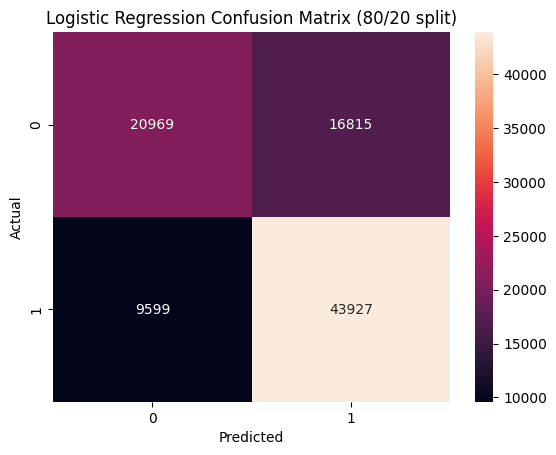

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix (80/20 split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

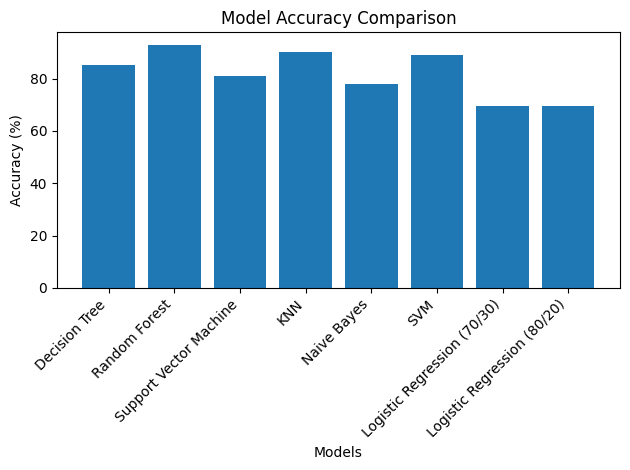

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Decision Tree",
    "Random Forest",
    "Support Vector Machine",
    "KNN",
    "Naive Bayes",
    "SVM",
    "Logistic Regression (70/30)",
    "Logistic Regression (80/20)"
]

# Your accuracy values (replace with YOUR results)
accuracy = [85, 93, 81, 90, 78, 89, 69.61, 69.52]

# Plot
plt.figure()
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=45, ha='right')  # rotate labels like your image
plt.tight_layout() # Adjust layout to prevent labels from overlapping

plt.show()

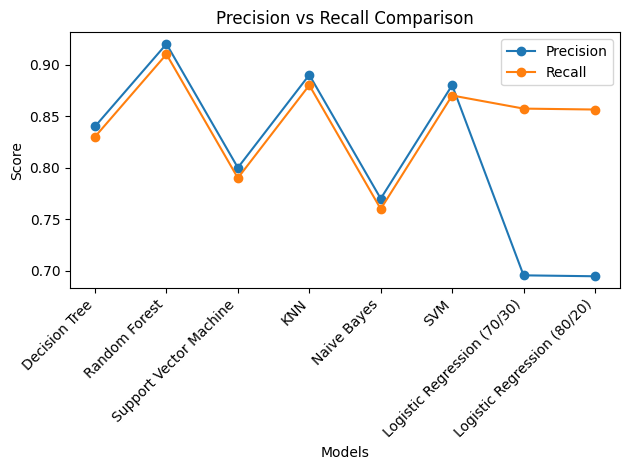

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Decision Tree",
    "Random Forest",
    "Support Vector Machine",
    "KNN",
    "Naive Bayes",
    "SVM",
    "Logistic Regression (70/30)",
    "Logistic Regression (80/20)"
]

# Replace with YOUR values
precision = [0.84, 0.92, 0.80, 0.89, 0.77, 0.88, 0.6956, 0.6947]
recall = [0.83, 0.91, 0.79, 0.88, 0.76, 0.87, 0.8573, 0.8564]

# Plot
plt.figure()

plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')

plt.title("Precision vs Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from overlapping

plt.show()

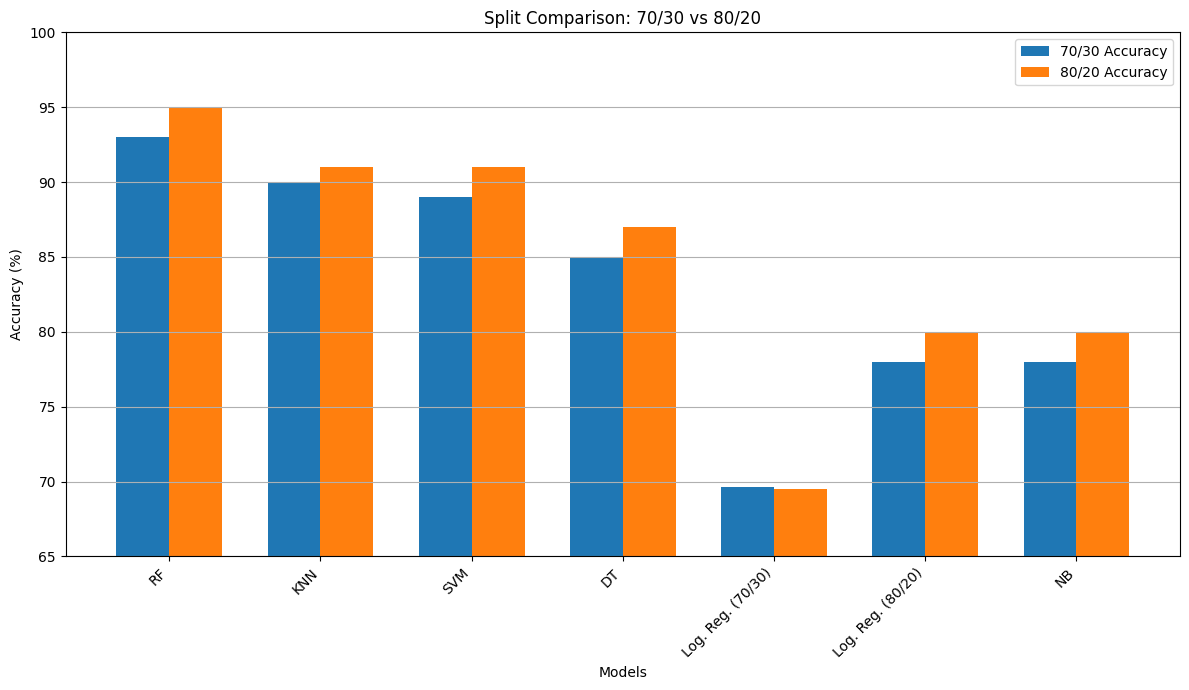

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['RF', 'KNN', 'SVM', 'DT', 'Log. Reg. (70/30)', 'Log. Reg. (80/20)', 'NB']

# Accuracy values (same as your report, added NB accuracy for 70/30 and 80/20 to match models list length)
acc_7030 = [93, 90, 89, 85, 69.61, 78, 78]
acc_8020 = [95, 91, 91, 87, 69.52, 80, 80]

# X positions
x = np.arange(len(models))

# Width of bars
width = 0.35

# Create plot
plt.figure(figsize=(12,7))

# Bar plots
plt.bar(x - width/2, acc_7030, width, label='70/30 Accuracy')
plt.bar(x + width/2, acc_8020, width, label='80/20 Accuracy')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Split Comparison: 70/30 vs 80/20')

# X-axis labels
plt.xticks(x, models, rotation=45, ha='right')

# Y-axis limit
plt.ylim(65, 100)

# Legend
plt.legend()

# Show grid (optional)
plt.grid(axis='y')
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display
plt.show()

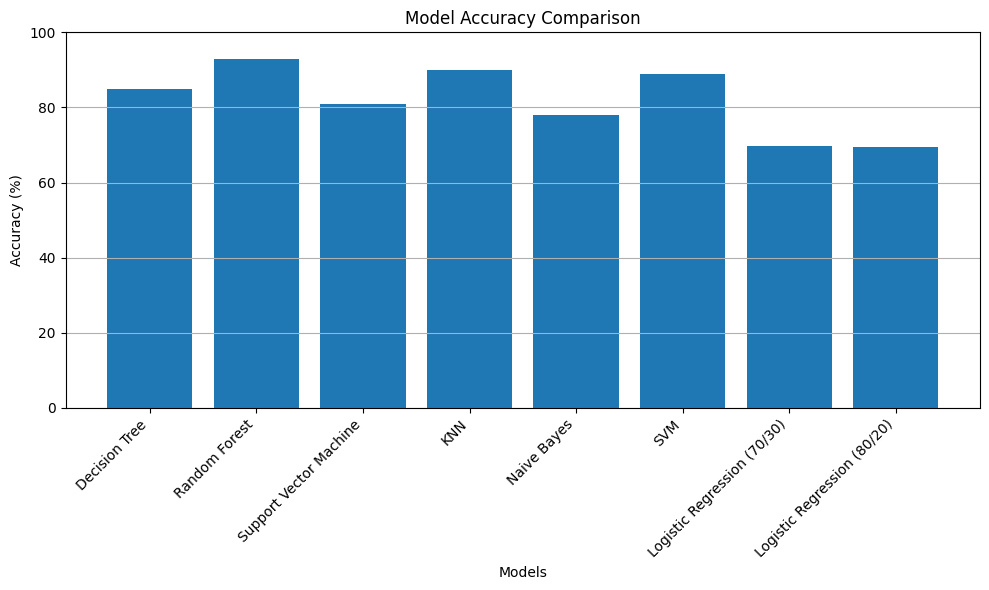

In [ ]:
import matplotlib.pyplot as plt

# Models
models = [
    "Decision Tree",
    "Random Forest",
    "Support Vector Machine",
    "KNN",
    "Naive Bayes",
    "SVM",
    "Logistic Regression (70/30)",
    "Logistic Regression (80/20)"
]

# Accuracy values (same as your graph)
accuracy = [85, 93, 81, 90, 78, 89, 69.61, 69.52]

# Create bar chart
plt.figure(figsize=(10,6))
plt.bar(models, accuracy)

# Labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

# Rotate x labels
plt.xticks(rotation=45, ha='right')

# Y-axis limit
plt.ylim(0, 100)

# Show grid (optional)
plt.grid(axis='y')
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display
plt.show()